# 2. AccessMod - Data Processing

This notebooks processes (computation, filtering, rasterization, etc.) the file that are downloaded in the notebook "1. AccessMod - Data Collection". 

To run the notebook, make sure that the paths are well defined. Also, you can modify the different parameters accordingly (filterging, land cover classes, roads, etc.)

Afterwards, you should be able to run all cells in the notebook. 

In [1]:
# import packages
import os
import shutil
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm import tqdm
import fiona
from shapely.ops import unary_union, nearest_points
from shapely.geometry import shape, Point
import rasterio
from rasterio.features import rasterize, shapes
from rasterio.transform import from_bounds
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import zonal_stats

In [2]:
# set data raw path (where files were downloaded)
data_path = '/Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data'
# set data pre-processed path (where the pre-processed files will be saved)
data_processed_path = data_path + '/data_processed'


In [3]:
# parameters 
iso = 'MAR'
# set epsg 
target_crs = 'EPSG:32629'
# set bbox for download
minx, miny, maxx, maxy = -7.752070332, 33.493328562, -7.451484890, 33.638278162

##---------------------
# land cover:
lulc_categories = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / sparse vegetation",
    70: "Snow and ice",
    80: "Permanent water bodies",
    90: "Herbaceous wetland",
    95: "Mangroves",
    100: "Moss and lichen",
}
# set the lists with the different types of land cover (walkable, exclusion, barriers)
list_walkable_codes = [10, 20, 30, 40, 50, 60, 100] # people can travel though 
list_exclusion_codes = [10, 40]  # people can travel through but no new facilities can be placed there
list_barrier_codes = [70, 80, 90, 95]  # people cannot travel though (and no facilities can be placed within barriers) - should not be in the walkable and exclusion list

##---------------------
# roads: 
# define the different road classes
dict_road_classes = {
                    1001:'primary',
                    1002:'secondary',
                    1003:'tertiary'
                    }
# dictionnary that will be used to remap the current classes to the ones defined above 
dict_remap_roads = {
                    # primary
                    'motorway':1001, 
                    'motorway_link':1001, 
                    'primary': 1001,
                    'primary_link':1001,
                    'trunk':1001,
                    'trunk_link':1001,
                    # secondary
                    'secondary':1002,
                    'secondary_link':1002,
                    # tertiary
                    'tertiary':1003,
                    'tertiary_link':1003
                    }

##---------------------
# scenario table: 
# modify it accordingly make sure that the class and labels exactly match with the land use and roads from above 
scenario_table = [
    {"class": 10, "label": "Tree_cover", "speed": 4, "mode": "WALKING"},
    {"class": 20, "label": "Shrubland", "speed": 3, "mode": "WALKING"},
    {"class": 30, "label": "Grassland", "speed": 4, "mode": "WALKING"},
    {"class": 40, "label": "Cropland", "speed": 4, "mode": "WALKING"},
    {"class": 50, "label": "Built-up", "speed": 4, "mode": "WALKING"},
    {"class": 60, "label": "Bare_sparse_vegetation", "speed": 3, "mode": "WALKING"},
    {"class": 100, "label": "Moss_and_lichen", "speed": 3, "mode": "WALKING"},
    {"class": 1001, "label": "Primary_road", "speed": 45.0, "mode": "MOTORISED"},
    {"class": 1002, "label": "Secondary_road", "speed": 30.0, "mode": "MOTORISED"},
    {"class": 1003, "label": "Tertiary_road", "speed": 20.0, "mode": "MOTORISED"}
]

In [4]:
# functions
def process_raster(src_path, dst_path, target_crs, shp_path=None, ref_path=None, resampling='bilinear'):
    
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    resampling_method = getattr(Resampling, resampling)

    # Read inputs
    with rasterio.open(src_path) as src:
        src_crs = src.crs
        src_transform = src.transform
        src_data = src.read(1)

        # Apply mask if shapefile provided 
        if shp_path:
            gdf = gpd.read_file(shp_path)
            print(" -> Masking will be applied after reprojection.")

        # Prepare target transform and dimensions 
        if ref_path:
            with rasterio.open(ref_path) as ref:
                dst_transform = ref.transform
                dst_width, dst_height = ref.width, ref.height
                print(" -> Using reference raster for resolution and extent.")
        else:
            dst_transform, dst_width, dst_height = calculate_default_transform(
                src_crs, target_crs, src.width, src.height, *src.bounds)
            print(" -> Calculated default transform for reprojection.")

        # Prepare output metadata
        dst_meta = src.meta.copy()
        dst_meta.update({
            'crs': target_crs,
            'transform': dst_transform,
            'width': dst_width,
            'height': dst_height
        })

        # Reproject
        dst_data = np.empty((src.count, dst_height, dst_width), dtype=src.dtypes[0])
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=dst_data[i - 1],
                src_transform=src_transform,
                src_crs=src_crs,
                dst_transform=dst_transform,
                dst_crs=target_crs,
                resampling=resampling_method
            )
        print("Reprojection completed.")

    # Mask 
    if shp_path:
        with rasterio.open(dst_path, 'w', **dst_meta) as temp_dst:
            temp_dst.write(dst_data)
        with rasterio.open(dst_path) as temp_src:
            out_data, out_transform = mask(temp_src, gpd.read_file(shp_path).geometry, crop=True)
            out_data = np.where(out_data == -99999, np.nan, out_data)
            dst_meta.update({
                "height": out_data.shape[1],
                "width": out_data.shape[2],
                "transform": out_transform
            })
            with rasterio.open(dst_path, 'w', **dst_meta) as dst:
                dst.write(out_data)
        print("Mask completed.")
    else:
        with rasterio.open(dst_path, 'w', **dst_meta) as dst:
            dst.write(dst_data)
        print("Raster saved without masking.")

    print(f"Processed raster saved to: {dst_path}")

def adjust_pop_by_ratio(raster_path, gdf_ratios, ratio_field, output_path):
    # Open raster
    with rasterio.open(raster_path) as src:
        meta = src.meta.copy()
    
        adjusted_data = np.zeros_like(src.read(1))
    
        for _, row in tqdm(gdf_ratios.iterrows(), total=len(gdf_ratios)):
            out_image, out_transform = mask(src, [row.geometry.__geo_interface__], crop=False)
            out_data = out_image[0] * row[ratio_field]
    
            adjusted_data[out_image[0] != src.nodata] += out_data[out_image[0] != src.nodata]
    
    # Write adjusted raster
    meta.update(dtype=rasterio.float32)
    
    with rasterio.open(output_path, "w", **meta) as dst:
        dst.write(adjusted_data.astype(rasterio.float32), 1)
    print(f'Adjusted population saved in: {output_path}')

def valid_shp(facility, area):
    if type(facility) == pd.DataFrame:
         # Convert to GeoDataFrame
        facility["geometry"] = facility.apply(lambda row: Point(row["Longitude"], row["Latitude"]), axis=1)
        facility = gpd.GeoDataFrame(facility, geometry="geometry")
        facility.set_crs(epsg=4326, inplace=True)
    
    if facility.crs != area.crs:
        area = area.to_crs(facility.crs)
    
    # Keep only points within Casablanca
    return gpd.sjoin(facility, area, predicate="within")

def find_possible_duplicates(gdf, source_a, source_b, distance_threshold=100):
    
    # Filter by data source
    gdf_a = gdf[gdf["Data Source"] == source_a].copy()
    gdf_b = gdf[gdf["Data Source"] == source_b].copy()
    
    # Project to a metric CRS for distance calculation (e.g., UTM or global EPSG:3857)
    gdf_a = gdf_a.to_crs(epsg=32629)
    gdf_b = gdf_b.to_crs(epsg=32629)
    
    # Create spatial index for faster lookup
    sindex_b = gdf_b.sindex
    
    possible_duplicates = []
    
    # Loop through features from source A
    for idx_a, row_a in gdf_a.iterrows():
        # Find nearby points within bounding box first (quick spatial filter)
        possible_matches_idx = list(sindex_b.intersection(row_a.geometry.buffer(distance_threshold).bounds))
        possible_matches = gdf_b.iloc[possible_matches_idx]
        
        # Compute actual distances
        for idx_b, row_b in possible_matches.iterrows():
            dist = row_a.geometry.distance(row_b.geometry)
            if dist <= distance_threshold:
                possible_duplicates.append({
                    "Name_A": row_a["Name"],
                    "Source_A": source_a,
                    "Name_B": row_b["Name"],
                    "Source_B": source_b,
                    "Distance_m": round(dist, 1)
                })
    
    # Convert to DataFrame for display
    import pandas as pd
    duplicates_df = pd.DataFrame(possible_duplicates)
    
    if duplicates_df.empty:
        print(f"No potential duplicates found between {source_a} and {source_b}.")
    else:
        print(f"Possible duplicates (within {distance_threshold} m) between {source_a} and {source_b}:")
        print(duplicates_df)
    
    return duplicates_df

## 2.1 Administrative boundaries

In [5]:
admin_levels = {
    'adm2': {
        'filename': 'mar_admbnda_adm2_hcp_20230925.SHP',
        'filter_field': 'ADM2_FR',
        'keep_fields': ['ADM2_FR', 'ADM2_AR', 'ADM2_PCODE', 'AREA_SQKM', 'geometry']
    },
    'adm3': {
        'filename': 'mar_admbnda_adm3_hcp_20230925.SHP',
        'filter_field': 'ADM2_FR',
        'keep_fields': ['ADM3_FR', 'ADM3_AR', 'ADM3_PCODE', 'AREA_SQKM', 'geometry']
    }
}
# process loop
output_path = os.path.join(data_processed_path, 'boundary')
os.makedirs(output_path, exist_ok=True)

for level, info in admin_levels.items():
    adm_loc = os.path.join(data_path, 'data_raw', 'boundary', info['filename'])
    print(f'\nProcessing {level.upper()} from {adm_loc}')
    
    gdf = gpd.read_file(adm_loc)   
    # filter for Casablanca province (ADM2_FR == 'Casablanca')
    gdf_casa = (
        gdf[gdf[info['filter_field']] == 'Casablanca']
        [info['keep_fields']]
        .to_crs(target_crs)
    )
     # save
    out_file = os.path.join(output_path, f'gdf_{level}_area.shp')
    gdf_casa.to_file(out_file, driver='ESRI Shapefile')
    print(f'Saved {level.upper()} boundaries to {out_file}')

print(f'\nAll administrative boundaries saved in: {output_path}')


Processing ADM2 from /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_raw/boundary/mar_admbnda_adm2_hcp_20230925.SHP
Saved ADM2 boundaries to /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/boundary/gdf_adm2_area.shp

Processing ADM3 from /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_raw/boundary/mar_admbnda_adm3_hcp_20230925.SHP
Saved ADM3 boundaries to /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/boundary/gdf_adm3_area.shp

All administrative boundaries saved in: /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/boundary


In [6]:
# Zonal for stat shapefile
gdf_zonal_for_stat = gdf_casa.copy()
# create unique ID colum (in int format)
gdf_zonal_for_stat['ADM3_ID'] = gdf_zonal_for_stat['ADM3_PCODE'].str[-3:].astype(int)
# export to shapefile
output_path = os.path.join(data_processed_path, 'zonalforstat', 'zonal_for_stat.shp')
os.makedirs(os.path.dirname(output_path), exist_ok=True)
gdf_zonal_for_stat.to_file(output_path, driver='ESRI Shapefile')
print(f'Zonal for Stat vector file saved in {output_path}')

Zonal for Stat vector file saved in /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/zonalforstat/zonal_for_stat.shp


## 2.2 Population

### 2.2.1 Census adjusted total population

In [7]:
# mask and reproject worldpop
raster_path = f'{data_path}/data_raw/population/mar_pop_2024_CN_100m_R2025A_v1.tif'
output_path = f'{data_processed_path}/population/casablanca_2024_total_pop_r2025a_v1.tif'
shp_path = f'{data_processed_path}/boundary/gdf_adm2_area.shp'

process_raster(raster_path, output_path, target_crs, shp_path, ref_path=None, resampling='bilinear')

 -> Masking will be applied after reprojection.
 -> Calculated default transform for reprojection.
Reprojection completed.
Mask completed.
Processed raster saved to: /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/population/casablanca_2024_total_pop_r2025a_v1.tif


In [8]:
# compute the population statistics and include it in the zonal for stat shapefile
with rasterio.open(output_path) as src:
        stats = zonal_stats(gdf_zonal_for_stat.to_crs(src.crs).geometry, src.read(1), affine = src.meta['transform'], 
                            stats = ['sum'], nodata = src.nodata, all_touched=False)
        # add statistics to gdf
        gdf_zonal_for_stat['wp_tot_pop'] = [stat['sum'] for stat in stats]
# export shapefile
output_path = os.path.join(data_processed_path, 'zonalforstat','zonal_for_stat.shp')
gdf_zonal_for_stat.to_file(output_path, driver='ESRI Shapefile')
print(f'Zonal for Stat vector file saved in {output_path}')

Zonal for Stat vector file saved in /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/zonalforstat/zonal_for_stat.shp


In [9]:
# read 2024 census population at ADM3 level
census_path = data_path + '/data_raw/population/2024_census_casablanca.csv'
col_en = ['ADM3_AR', 'ADM3_FR', 'census_%_below_15', 'census_%_female_15_to_59', 'census_pop_total', 'census_pop_female']
df_census = pd.read_csv(census_path)
df_census.columns = col_en

gdf_casa.loc[gdf_casa.ADM3_FR=='Ben M\'Sick', 'ADM3_AR'] = 'ابن مسيك'
gdf_casa.loc[gdf_casa.ADM3_FR=='Mechouar de Casablanca', 'ADM3_AR'] = 'مشور الدار البيضاء'

adm3_census_pop = gdf_casa.drop('ADM3_FR', axis=1).merge(df_census, on='ADM3_AR')
adm3_census_pop = adm3_census_pop.merge(gdf_zonal_for_stat[['ADM3_PCODE', 'wp_tot_pop']], on='ADM3_PCODE', how="left")
adm3_census_pop['total_pop_adj_ratio'] = adm3_census_pop['census_pop_total'] / adm3_census_pop['wp_tot_pop']
adm3_census_pop['female_pop_adj_ratio'] = adm3_census_pop['census_pop_female'] / adm3_census_pop['census_pop_total']
adm3_census_pop['census_%_female_15_to_59'] = adm3_census_pop['census_%_female_15_to_59'] / 100
adm3_census_pop['census_%_below_15'] = adm3_census_pop['census_%_below_15'] / 100

# compute census adjusted total population
raster_path = f'{data_processed_path}/population/casablanca_2024_total_pop_r2025a_v1.tif'
output_path = f'{data_processed_path}/population/adj_casablanca_2024_total_pop_r2025a_v1.tif'

adjust_pop_by_ratio(raster_path, adm3_census_pop, 'total_pop_adj_ratio', output_path)

100%|██████████████████████████████████████████| 17/17 [00:00<00:00, 289.98it/s]

Adjusted population saved in: /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/population/adj_casablanca_2024_total_pop_r2025a_v1.tif


### 2.2.2 Population (by sex and age)


In [10]:
# compute census adjusted female population
raster_path = f'{data_processed_path}/population/adj_casablanca_2024_total_pop_r2025a_v1.tif'
output_path = f'{data_processed_path}/population/adj_casablanca_2024_f_total_pop_r2025a_v1.tif'

adjust_pop_by_ratio(raster_path, adm3_census_pop, 'female_pop_adj_ratio', output_path)

# compute census adjusted 15 to 59 female population
raster_path = f'{data_processed_path}/population/adj_casablanca_2024_f_total_pop_r2025a_v1.tif'
output_path = f'{data_processed_path}/population/adj_casablanca_2024_f_15_59_pop_r2025a_v1.tif'

adjust_pop_by_ratio(raster_path, adm3_census_pop, 'census_%_female_15_to_59', output_path)

# compute census adjusted 15 to 59 female population
raster_path = f'{data_processed_path}/population/adj_casablanca_2024_f_total_pop_r2025a_v1.tif'
output_path = f'{data_processed_path}/population/adj_casablanca_2024_f_15_59_pop_r2025a_v1.tif'

adjust_pop_by_ratio(raster_path, adm3_census_pop, 'census_%_female_15_to_59', output_path)

100%|██████████████████████████████████████████| 17/17 [00:00<00:00, 314.65it/s]


Adjusted population saved in: /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/population/adj_casablanca_2024_f_total_pop_r2025a_v1.tif


100%|██████████████████████████████████████████| 17/17 [00:00<00:00, 331.95it/s]


Adjusted population saved in: /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/population/adj_casablanca_2024_f_15_59_pop_r2025a_v1.tif


100%|██████████████████████████████████████████| 17/17 [00:00<00:00, 267.22it/s]


Adjusted population saved in: /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/population/adj_casablanca_2024_f_15_59_pop_r2025a_v1.tif


#### Estimate 2024 Child Population 

| Age group | Sex / Category | Population |
|------------|----------------|-------------:|
| 0–4 years | Male | 1,606,550 |
| 0–4 years | Female | 1,539,194 |
| 0–14 years | Total | 9,761,312 |

**Source:** DataBank by World Bank – *[Population estimates and projections](https://databank.worldbank.org/source/population-estimates-and-projections)*.

In [11]:
# compute census adjusted 0 to 4 population

## ratio of 0-4 / 0-14 (from the World Bank table above)
r = (1606550 + 1539194) / 9761312
adm3_census_pop['est_census_%_0_4'] = adm3_census_pop['census_%_below_15'] * r
raster_path = f'{data_processed_path}/population/adj_casablanca_2024_total_pop_r2025a_v1.tif'
output_path = f'{data_processed_path}/population/adj_casablanca_2024_0_4_pop_r2025a_v1.tif'

adjust_pop_by_ratio(raster_path, adm3_census_pop, 'est_census_%_0_4', output_path)

100%|██████████████████████████████████████████| 17/17 [00:00<00:00, 187.00it/s]


Adjusted population saved in: /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/population/adj_casablanca_2024_0_4_pop_r2025a_v1.tif


In [12]:
# add the population statistics and include it in the zonal for stat shapefile
output_path = os.path.join(data_processed_path, 'zonalforstat','zonal_for_stat.shp')

adm3_census_pop = adm3_census_pop.rename({'census_pop_total':'pop_total', 'census_pop_female':'pop_f'}, axis=1)
adm3_census_pop['pop_0_4'] = adm3_census_pop['est_census_%_0_4'] * adm3_census_pop['pop_total']
adm3_census_pop['pop_f15_59'] = adm3_census_pop['census_%_female_15_to_59'] * adm3_census_pop['pop_total']
adm3_census_pop['pop_0_14'] = adm3_census_pop['census_%_below_15'] * adm3_census_pop['pop_total']
adm3_census_pop['pop_m'] = adm3_census_pop['pop_total'] - adm3_census_pop['pop_f']

# export tabular population count to zonal for stat
pop_list = ['ADM3_AR', 'ADM3_FR', 'ADM3_PCODE', 'AREA_SQKM', 'geometry', 'wp_tot_pop', 'pop_total', 'pop_f', 'pop_0_4', 'pop_f15_59', 'pop_0_14', 'pop_m']
adm3_census_pop[pop_list].to_file(output_path, driver='ESRI Shapefile')

## 2.3 DEM

In [13]:
# copy dem to pre-processed folder (no pre-processing needed)
raster_path = f'{data_path}/data_raw/dem/srtm_35_06.tif'
output_path = f'{data_processed_path}/dem/casablanca_srtm_35_06.tif'
shp_path = f'{data_processed_path}/boundary/gdf_adm2_area.shp'
ref_path = f'{data_processed_path}/population/adj_casablanca_2024_total_pop_r2025a_v1.tif'

process_raster(raster_path, output_path, target_crs, shp_path, ref_path, resampling='bilinear')

 -> Masking will be applied after reprojection.
 -> Using reference raster for resolution and extent.
Reprojection completed.
Mask completed.
Processed raster saved to: /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/dem/casablanca_srtm_35_06.tif


## 2.4 Land Cover

In [14]:
raster_path = f'{data_path}/data_raw/lulc/ESA_WorldCover_10m_2021_V200_N33W009_Map.tif'
output_path = f'{data_processed_path}/lulc/casablanca_esa_worldcover_v200.tif'
shp_path = f'{data_processed_path}/boundary/gdf_adm2_area.shp'
ref_path = f'{data_processed_path}/population/adj_casablanca_2024_total_pop_r2025a_v1.tif'

process_raster(raster_path, output_path, target_crs, shp_path, ref_path, resampling='nearest')

 -> Masking will be applied after reprojection.
 -> Using reference raster for resolution and extent.
Reprojection completed.
Mask completed.
Processed raster saved to: /Users/carla_q/Library/CloudStorage/GoogleDrive-kchen@datapopalliance.org/My Drive/Morocco care mapping/data/data_processed/lulc/casablanca_esa_worldcover_v200.tif


### 2.4.1 Land Cover Table

In [15]:
output_path = f'{data_processed_path}/lulc/land_cover_table.csv'

# convert dict to tbale
table_lc = pd.DataFrame(list(lulc_categories.items()), columns=['class', 'label'])
# export to csv
table_lc.to_csv(output_path, index=False)

## 2.5 Exclusion Areas

In [16]:
raster_path = f'{data_processed_path}/lulc/casablanca_esa_worldcover_v200.tif'
output_path = f'{data_processed_path}/lulc/casablanca_esa_worldcover_v200_exclusion.shp'

with rasterio.open(raster_path) as src:
    landcover = src.read(1)
    transform = src.transform
    crs = src.crs

# Create a binary mask for barriers
exclusion_mask = np.isin(landcover, list_exclusion_codes).astype(np.uint8)

# Generate polygons from the barrier mask
polygons = [shape(geom) for geom, value in shapes(exclusion_mask, mask=exclusion_mask, transform=transform) if value == 1]

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(geometry=polygons, crs=crs)

# Save to shapefile
gdf.to_file(output_path)

## 2.6 Barrier Areas

In [17]:
raster_path = f'{data_processed_path}/lulc/casablanca_esa_worldcover_v200.tif'
output_path = f'{data_processed_path}/lulc/casablanca_esa_worldcover_v200_barrier.shp'

with rasterio.open(raster_path) as src:
    landcover = src.read(1)
    transform = src.transform
    crs = src.crs

# Create a binary mask for barriers
barrier_mask = np.isin(landcover, list_barrier_codes).astype(np.uint8)

# Generate polygons from the barrier mask
polygons = [shape(geom) for geom, value in shapes(barrier_mask, mask=barrier_mask, transform=transform) if value == 1]

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(geometry=polygons, crs=crs)

# Save to shapefile
gdf.to_file(output_path)

## 2.7 Facilities

In [18]:
gov_path = f'{data_path}/data_raw/facility/casa_pub_childcare.csv'
osm_path = f'{data_path}/data_raw/facility/hotosm_mar_education_facilities_points_gpkg.gpkg'
ggl_path = f'{data_path}/data_raw/facility/casa_google_childcare.csv'
shp_path = f'{data_processed_path}/boundary/gdf_adm2_area.shp'
# read study area
shp = gpd.read_file(shp_path)

#### Step 1. Remove facilities outside of Casablanca
##### Administrative Data
As all 39 facilities were extracted from `casablancacity.ma/fr`, all of them are selected.
##### Google Maps
There are 193 valid childcare facilities filtered from 220.
##### OSM
Out of 35 facilities, there are only two facilities within Casablanca, and only the second one is eligible.
- **Amira Lalla Aïcha** is a primary school according to [google map](https://maps.app.goo.gl/C6LdxuVYCGL284Xo7)
- **Lahlou** provides education for children at 3 year old according to [google map comments](https://maps.app.goo.gl/JVKHT4y2mkYNQpgk6)

In [19]:
# filter out facilities outside of the study area
gov_valid = valid_shp(pd.read_csv(gov_path), shp)
ggl_valid = valid_shp(pd.read_csv(ggl_path), shp)
osm_valid = valid_shp(gpd.read_file(osm_path), shp)
osm_valid

,name,name:en,amenity,building,operator:type,capacity:persons,addr:full,addr:city,source,name:ar,name:ber,osm_id,osm_type,geometry,index_right,ADM2_FR,ADM2_AR,ADM2_PCODE,AREA_SQKM
6,Amira Lalla Aïcha,None,None,school,None,None,None,None,None,None,None,3124330553,nodes,POINT (-7.60618 33.5759),0,Casablanca,الدار البيضاء,MA002005,219.221088
25,Lahlou,None,None,school,None,None,None,None,None,None,None,3359702414,nodes,POINT (-7.62496 33.59442),0,Casablanca,الدار البيضاء,MA002005,219.221088


In [20]:
keep_list = ['Name', 'Latitude', 'Longitude', 'Data Source', 'Category', 'geometry']
osm_single = gpd.GeoDataFrame(
    {
        "Name": "Lahlou",
        "Latitude": 33.59442,
        "Longitude": -7.62496,
        "Data Source": "OSM",
        "Category": "School",
        "geometry": [Point(-7.62496, 33.59442)] 
    },
    crs="EPSG:4326"  
)
gov_valid['Category'] = 'Toddler Care'
facilities_all = gpd.GeoDataFrame(pd.concat([ggl_valid[keep_list], gov_valid[keep_list]], ignore_index=True))
facilities_all = gpd.GeoDataFrame(pd.concat([facilities_all, osm_single], ignore_index=True))

#### Step 2. Detect duplicated facilities
200 meters were used as the distance threshold. No duplicated facilities between 
- **OSM and Google**: no duplicates
- **OSM and Admin**: no duplicates
- **Google and Admin**: 8 potential duplicates, but after checking names below, they are just nearby facilities, not duplicates.

In [21]:
print("--------------------------Google and OSM--------------------------- ")
_ = find_possible_duplicates(facilities_all, "Google", "OSM", distance_threshold=200)
print('')
print("--------------------------Admin data and OSM--------------------------- ")
_ = find_possible_duplicates(facilities_all, "Public", "OSM", distance_threshold=200)
print('')
print("--------------------------Admin data and Google--------------------------- ")
_ = find_possible_duplicates(facilities_all, "Public", "Google", distance_threshold=200)

--------------------------Google and OSM--------------------------- 
No potential duplicates found between Google and OSM.

--------------------------Admin data and OSM--------------------------- 
No potential duplicates found between Public and OSM.

--------------------------Admin data and Google--------------------------- 
Possible duplicates (within 200 m) between Public and Google:
                                       Name_A Source_A  \
0                         Garderie Tizi Ousli   Public   
1                       Garderie Derb Ghallef   Public   
2                               Garderie Badr   Public   
3                               Garderie Badr   Public   
4                               Garderie Badr   Public   
5               Garderie Ibnou Dor Al Ghafiri   Public   
6           Centre socio‑éducatif Mouahiddine   Public   
7  Centre Sidi Moumen de Développement Humain   Public   

                                              Name_B Source_B  Distance_m  
0          

In [22]:
# export shapefile
output_path = f'{data_processed_path}/facility/'
os.makedirs(output_path, exist_ok=True)
facilities_all.to_file(output_path+'gdf_facility.shp', driver='ESRI Shapefile')

/var/folders/ff/d9hsf_d15p74s7h098v4mqrh0000gn/T/ipykernel_60119/652998012.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  facilities_all.to_file(output_path+'gdf_facility.shp', driver='ESRI Shapefile')
/Users/carla_q/miniforge3/envs/unw_vn/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Data Source' to 'Data Sourc'
  ogr_write(


## 2.8 Roads

<Axes: >

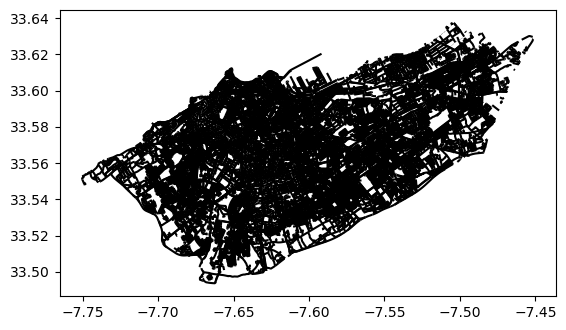

In [23]:
gpkg_path = f'{data_path}/data_raw/road/hotosm_mar_roads.gpkg'
output_path = f'{data_processed_path}/road/'

road = valid_shp(gpd.read_file(gpkg_path), shp)
road.plot(color='black')

In [24]:
gdf_roads = road.copy()
# remap class_n based on type
gdf_roads['class_n'] =  gdf_roads['highway'].map(dict_remap_roads)
# drop nan values (road types not remapped) 
gdf_roads= gdf_roads.dropna(subset=["class_n"]).copy()
# set int type for class_n
gdf_roads['class_n'] = gdf_roads['class_n'].astype(int)
# remap label based on class
gdf_roads['label'] =  gdf_roads['class_n'].map(dict_road_classes)
# keep relevant columns
gdf_roads = gdf_roads[['geometry', 'class_n', 'label']]

# export shapefile
os.makedirs(os.path.dirname(output_path), exist_ok=True)
gdf_roads.to_crs(target_crs).to_file(output_path+'hotosm_casablanca_road.shp', driver='ESRI Shapefile')

## 2.9 Scenario table

In [25]:
# create the scenario table based on parameters given in the beginning 
# convert dictionnary to pandas DataFrame
table_scenario_table = pd.DataFrame(scenario_table)
# export to csv
output_path = f'{data_processed_path}/travel/'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
table_scenario_table.to_csv(output_path+'scenario_table.csv', index=False)